In [17]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [2]:
def load_peak_stats_for_cell(stats_path, cell_name, usecols=None, chunksize=50000):
    """
    Load only rows for one cell from a large peak-stats CSV.

    Parameters
    ----------
    stats_path : str or Path
    cell_name : str
        Example: "cell_3"
    usecols : list or None
        Columns to load. If None, loads all columns.
    chunksize : int
        Number of rows per chunk.

    Returns
    -------
    pd.DataFrame
    """
    stats_path = Path(stats_path)

    if usecols is not None and "cell" not in usecols:
        usecols = ["cell"] + list(usecols)

    chunks = []
    for chunk in pd.read_csv(stats_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        sub = chunk.loc[chunk["cell"] == cell_name]
        if not sub.empty:
            chunks.append(sub)

    if not chunks:
        return pd.DataFrame(columns=usecols if usecols is not None else None)

    return pd.concat(chunks, ignore_index=True)

def list_cells_in_peak_stats(stats_path, chunksize=50000):
    seen = set()
    for chunk in pd.read_csv(stats_path, usecols=["cell"], chunksize=chunksize):
        seen.update(chunk["cell"].dropna().unique())

    def natural_cell_key(name):
        m = re.match(r"cell_(\d+)$", str(name))
        if m:
            return (0, int(m.group(1)))
        return (1, str(name))

    return sorted(seen, key=natural_cell_key)




In [19]:
# for loading ActSort labels 
def cell_name_to_matlab_idx(cell_name):
    m = re.fullmatch(r"cell_(\d+)", str(cell_name))
    if m is None:
        raise ValueError(f"Could not parse cell name: {cell_name}")
    return int(m.group(1))  # MATLAB-style cell number, e.g. cell_1 -> 1

def is_good_cell(cell_name, labels_overall):
    matlab_idx = cell_name_to_matlab_idx(cell_name)
    python_idx = matlab_idx - 1  # convert MATLAB 1-indexing to Python 0-indexing
    if python_idx < 0 or python_idx >= len(labels_overall):
        return False
    return labels_overall[python_idx] == 1

In [3]:
##path to dataframe 
stats_path = Path("/scratch/jma819/CaliAli_linearTrackData/m994_analysis/all_peak_stats_20260518_211705.csv")

#matching full Ca2+ traces for full length of traces 
csv_path = Path("/scratch/jma819/CaliAli_linearTrackData/m994_analysis/GCAMP_with_velocity.csv")
with csv_path.open("r") as f:
    n_rows = sum(1 for _ in f) - 1  # subtract header


In [4]:
#preview only a few rows 
preview_df = pd.read_csv(stats_path, nrows=10)
preview_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_0,0,3620,3514,39615,7.541232,36101,3504,39625
1,cell_0,1,6416,5986,10764,4.461650,4778,5976,10774
2,cell_0,2,7910,7800,8817,4.461650,1017,7790,8827
3,cell_0,3,8093,7800,8817,4.461650,1017,7790,8827
4,cell_0,4,8801,8632,8817,3.510400,185,8622,8827
5,cell_0,5,20156,20102,20174,3.913802,72,20092,20184
6,cell_0,6,21366,21155,21439,3.665413,284,21145,21449
7,cell_0,7,23226,22938,23329,4.639365,391,22928,23339
8,cell_0,8,24919,24862,25154,7.541232,292,24852,25164
9,cell_0,9,25061,24862,25154,7.541232,292,24852,25164


In [5]:
#list cells in recording
cells = list_cells_in_peak_stats(stats_path)
cells[:20]

['cell_0',
 'cell_2',
 'cell_4',
 'cell_5',
 'cell_6',
 'cell_7',
 'cell_9',
 'cell_10',
 'cell_11',
 'cell_13',
 'cell_15',
 'cell_16',
 'cell_18',
 'cell_19',
 'cell_22',
 'cell_23',
 'cell_25',
 'cell_27',
 'cell_28',
 'cell_29']

In [6]:
# load one cell 
cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name="cell_29")


In [7]:
cell_stats_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_29,0,578,392,930,4.234892,538,382,940
1,cell_29,1,1204,1095,3311,6.062009,2216,1085,3321
2,cell_29,2,1614,1446,243047,21.578249,241601,1436,243047
3,cell_29,3,2503,2448,2576,3.478783,128,2438,2586
4,cell_29,4,3474,3363,3763,4.428940,400,3353,3773
...,...,...,...,...,...,...,...,...,...
350,cell_29,350,238138,237917,238171,11.682369,254,237907,238181
351,cell_29,351,238269,238222,238511,21.578249,289,238212,238521
352,cell_29,352,238345,238279,238511,5.169471,232,238269,238521
353,cell_29,353,238416,238279,238511,5.169471,232,238269,238521


In [8]:
cell_stats_df.onset_idx

0         392
1        1095
2        1446
3        2448
4        3363
        ...  
350    237917
351    238222
352    238279
353    238279
354    241011
Name: onset_idx, Length: 355, dtype: int64

In [9]:
n_rows

243048

In [10]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
window_len = 20
onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")


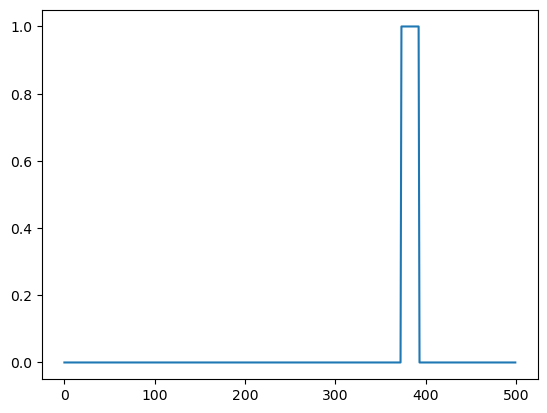

In [11]:
plt.plot(eventsPerSecond_convolve[0:500])

In [ ]:
# refilter cells using ActSort labels 

In [23]:
labels_path = Path("/scratch/jma819/CaliAli_linearTrackData/m994_analysis/precomputed_output_LABELS.mat")
mat = sio.loadmat(labels_path, squeeze_me=True, struct_as_record=False)
labels = mat["labels"]
labels_ex = np.asarray(labels.labels_ex).squeeze().astype(int)
labels_ml = np.asarray(labels.labels_ml).squeeze().astype(int)
labels_overall = np.asarray(labels.labels_overall).squeeze().astype(int)

In [24]:
# get good cells 
cells = list_cells_in_peak_stats(stats_path)
good_cells = [cell for cell in cells if is_good_cell(cell, labels_overall)]

In [31]:
len(good_cells)

989

In [32]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window for all cells 
events_per_second_dict={}
for cell in good_cells:
    print(cell)
    cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name=cell)
    # calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
    window_len = 20
    onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
    eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")
    events_per_second_dict[cell] = eventsPerSecond_convolve

cell_5
cell_6
cell_7
cell_10
cell_16
cell_23
cell_28
cell_30
cell_34
cell_35
cell_36
cell_37
cell_39
cell_40
cell_44
cell_45
cell_48
cell_49
cell_51
cell_52
cell_53
cell_54
cell_57
cell_58
cell_59
cell_60
cell_62
cell_63
cell_64
cell_68
cell_69
cell_73
cell_74
cell_75
cell_77
cell_78
cell_79
cell_80
cell_81
cell_82
cell_84
cell_85
cell_86
cell_87
cell_92
cell_94
cell_95
cell_96
cell_99
cell_100
cell_101
cell_104
cell_107
cell_108
cell_110
cell_113
cell_114
cell_115
cell_119
cell_123
cell_124
cell_126
cell_127
cell_128
cell_130
cell_131
cell_132
cell_135
cell_136
cell_137
cell_138
cell_140
cell_141
cell_142
cell_143
cell_146
cell_147
cell_148
cell_149
cell_154
cell_155
cell_157
cell_159
cell_160
cell_164
cell_165
cell_166
cell_167
cell_173
cell_174
cell_175
cell_178
cell_182
cell_183
cell_185
cell_192
cell_193
cell_195
cell_197
cell_198
cell_199
cell_202
cell_204
cell_206
cell_207
cell_211
cell_214
cell_217
cell_219
cell_226
cell_227
cell_229
cell_230
cell_231
cell_233
cell_234
cell_235

In [33]:
eventsPerSecond_df = pd.DataFrame(events_per_second_dict)

In [34]:
eventsPerSecond_df.mean(axis=0)

cell_5       0.036786
cell_6       0.038761
cell_7       0.024359
cell_10      0.029297
cell_16      0.031601
               ...   
cell_1874    0.016875
cell_1875    0.008888
cell_1876    0.011768
cell_1877    0.019257
cell_1878    0.014237
Length: 989, dtype: float64

In [36]:
save_path = Path("/scratch/jma819/CaliAli_linearTrackData/m994_analysis/eventsPerSecond_df.csv")
eventsPerSecond_df.to_csv(save_path, index=True)

print(save_path)

/scratch/jma819/CaliAli_linearTrackData/m994_analysis/eventsPerSecond_df.csv


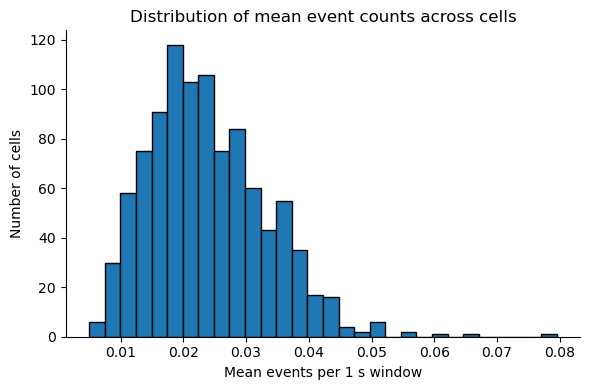

In [35]:
# histogram of firing rate across all cells
import matplotlib.pyplot as plt

mean_events_per_cell = eventsPerSecond_df.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_events_per_cell, bins=30, edgecolor="black")
ax.set_xlabel("Mean events per 1 s window")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of mean event counts across cells")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
